# Taylor–Green vortex: viscous decay in a periodic box

The simplest closed-form flow with a pressure field: the vortex array

$$u = U\,(-\cos kx\,\sin ky,\ \sin kx\,\cos ky),\qquad k = 2\pi$$

in the periodic unit box decays as $e^{-2\nu k^2 t}$ in amplitude, i.e. the kinetic energy as $E(t)/E(0) = e^{-4\nu k^2 t}$ (the nonlinear term is balanced by the pressure gradient and does not
change the decay). It tests the **fluid** operators alone — viscosity, pressure, particle shifting — with no wall in the domain.

Choose the solver with `SCHEME`:

* `"delta"` — weakly compressible δ⁺-SPH (`DeltaSPH2D`): equation of state, speed of sound $c_0 = 10U$, particle shifting.
* `"dfsph"` — divergence-free SPH (`DFSPH2D`): the converged compact projection that the solver selects for fully periodic domains (non-dissipative, tolerance-insensitive).

Both are driven through the same description (`make_solver`): lattice, viscosity, periodic box.

In [1]:
SCHEME = "delta"      # "delta" | "dfsph"
QUALITY = "quick"     # "quick" (about a minute) | "full" (finer lattice, longer)
DEVICE = "cuda:0"

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt

import warpSPHBoundaries  # noqa: F401  (selects the float64 default precision)
from warpSPHBoundaries.scene.periodic import Periodic
from warpSPHBoundaries.sim.references import tgv_energy
from warpSPHBoundaries.sim.solvers import make_solver, lattice

n = {"quick": 32, "full": 64}[QUALITY]          # particles per unit length
nu, U, T = 0.0185, 0.1, {"quick": 2.0, "full": 3.0}[QUALITY]
dx, k = 1.0 / n, 2 * math.pi
print(f"scheme {SCHEME}, {n}x{n} particles, nu = {nu}, Re = U/(nu k) = {U / (nu * k):.2f}, final time {T}")

scheme delta, 32x32 particles, nu = 0.0185, Re = U/(nu k) = 0.86, final time 2.0


## Set-up
The initial lattice has spacing `dx`; the solver wrapper chooses the support, the particle volume and (for `delta`) the speed of sound and the viscosity coefficient for the requested kinematic viscosity.

In [3]:
pos = lattice((0, 0), (1, 1), dx)
vel = U * np.stack([-np.cos(k * pos[:, 0]) * np.sin(k * pos[:, 1]), np.sin(k * pos[:, 0]) * np.cos(k * pos[:, 1])], 1)
extra = {"maxDt": 5e-3} if SCHEME == "dfsph" else {}
sol = make_solver(SCHEME, pos, dx, None, nu=nu, vel=vel, periodic=Periodic((0, 0), (1, 1)), c0=10 * U, device=DEVICE, **extra)

def kinetic(s):
    return 0.5 * float((s.volume * (s.v ** 2).sum(1)).sum())

E0 = kinetic(sol)
t, E, rho_lo, rho_hi = [0.0], [E0], [float(sol.rho.min())], [float(sol.rho.max())]

def record(s):
    t.append(s.time); E.append(kinetic(s)); rho_lo.append(float(s.rho.min())); rho_hi.append(float(s.rho.max()))

## Integration

In [4]:
sol.run(T, every=T / 4, callback=record, report=lambda s: f"E/E0 {E[-1] / E0:.4f}  exact {tgv_energy(s.time, nu)[()]:.4f}")

  t    0.510  dt 1.00e-02  vmax    0.048  E/E0 0.2332  exact 0.2255  [2 s]


  t    1.010  dt 1.00e-02  vmax    0.023  E/E0 0.0560  exact 0.0523  [3 s]


  t    1.510  dt 1.00e-02  vmax    0.012  E/E0 0.0135  exact 0.0121  [4 s]


  t    2.010  dt 1.00e-02  vmax    0.006  E/E0 0.0032  exact 0.0028  [5 s]


True

## Comparison with the exact decay

decay rate / analytic = 0.9761   (E/E0 at t = 2.01: 0.003232, exact 0.002819)
density band over the run: [0.9940, 1.0062]


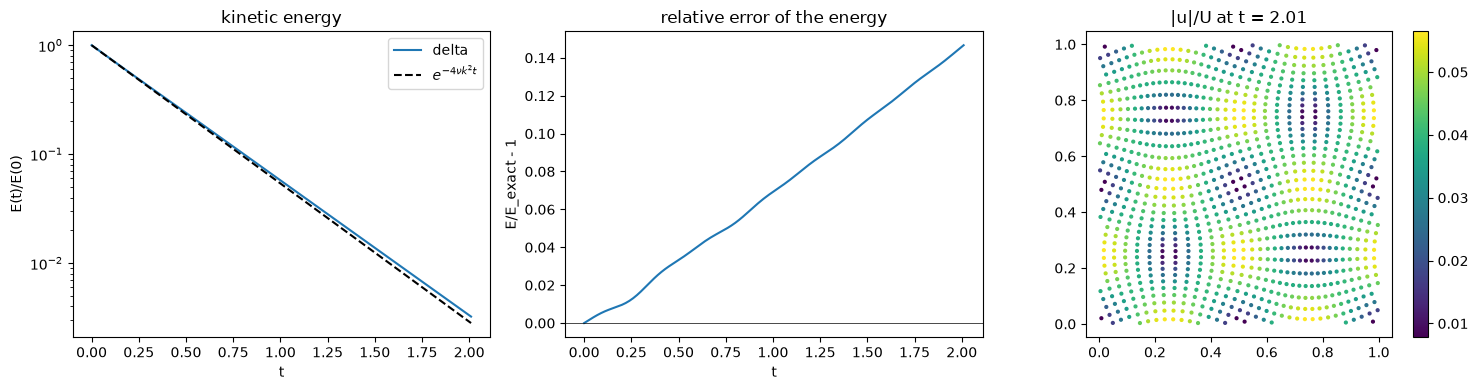

In [5]:
t, E = np.array(t), np.array(E) / E0
exact = tgv_energy(t, nu)
sel = (E > 1e-3) & (t > 0.1 * T)
rate = -np.polyfit(t[sel], np.log(E[sel]), 1)[0]
print(f"decay rate / analytic = {rate / (4 * nu * k * k):.4f}   (E/E0 at t = {t[-1]:.2f}: {E[-1]:.4g}, exact {exact[-1]:.4g})")
print(f"density band over the run: [{min(rho_lo):.4f}, {max(rho_hi):.4f}]")

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].semilogy(t, E, label=SCHEME); ax[0].semilogy(t, exact, "k--", label=r"$e^{-4\nu k^2 t}$")
ax[0].set(xlabel="t", ylabel="E(t)/E(0)", title="kinetic energy"); ax[0].legend()
ax[1].plot(t, E / exact - 1); ax[1].axhline(0, color="k", lw=0.5); ax[1].set(xlabel="t", ylabel="E/E_exact - 1", title="relative error of the energy")
x, v = sol.x, sol.v
q = ax[2].scatter(np.mod(x[:, 0], 1), np.mod(x[:, 1], 1), c=np.linalg.norm(v, axis=1) / U, s=4, cmap="viridis")
ax[2].set(aspect="equal", title=f"|u|/U at t = {sol.time:.2f}"); plt.colorbar(q, ax=ax[2])
plt.tight_layout(); plt.show()

## What to look at

* the decay rate over the analytic one is the effective viscosity of the discretisation: the calibrated Morris operator is within a few per cent at this resolution, for both solvers;
* the density band is the density error of the run: for `delta` the weak compressibility (of order $\mathrm{Ma}^2$ plus the shifting), for `dfsph` what the pressure solve leaves of $\rho-\rho_0$;
* run it again with `QUALITY = "full"` to see the error shrink with resolution.